In [710]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV,cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder,OrdinalEncoder
from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error, mean_absolute_error, r2_score, mean_absolute_error

from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

import torch 
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms




from scipy.stats import  randint, uniform, loguniform
from sklearn.base import BaseEstimator
import warnings
warnings.filterwarnings('ignore')

# EDA

In [461]:
df_train = pd.read_csv('data/train.csv')
df_test = pd.read_csv('data/test.csv')

df_train.shape, df_test.shape

((1460, 81), (1459, 80))

In [462]:
df_train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [463]:
df_train.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [464]:
df_train['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [465]:
df_train = df_train.drop(df_train[(df_train['GrLivArea'] > 4000) & (df_train['SalePrice'] < 300000)].index)

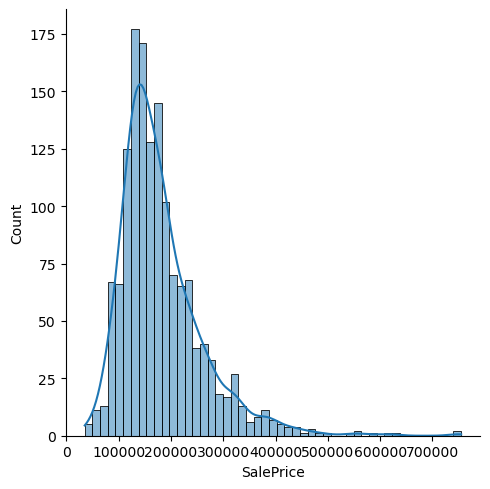

In [466]:
sns.displot(df_train['SalePrice'],kde = True)

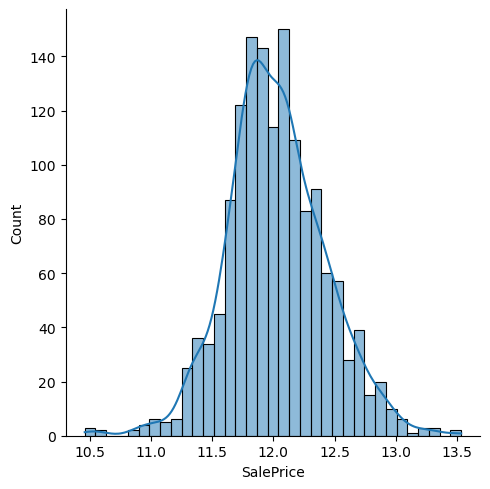

In [467]:
sns.displot(np.log1p(df_train['SalePrice']),kde = True)

при обучении будем использовать именно log(y) так как его распрделение приближенно к нормальному

In [468]:
y = df_train['SalePrice']
X = df_train.drop(columns=['Id','SalePrice'],axis = 1)
y.shape, X.shape

((1458,), (1458, 79))

<Axes: >

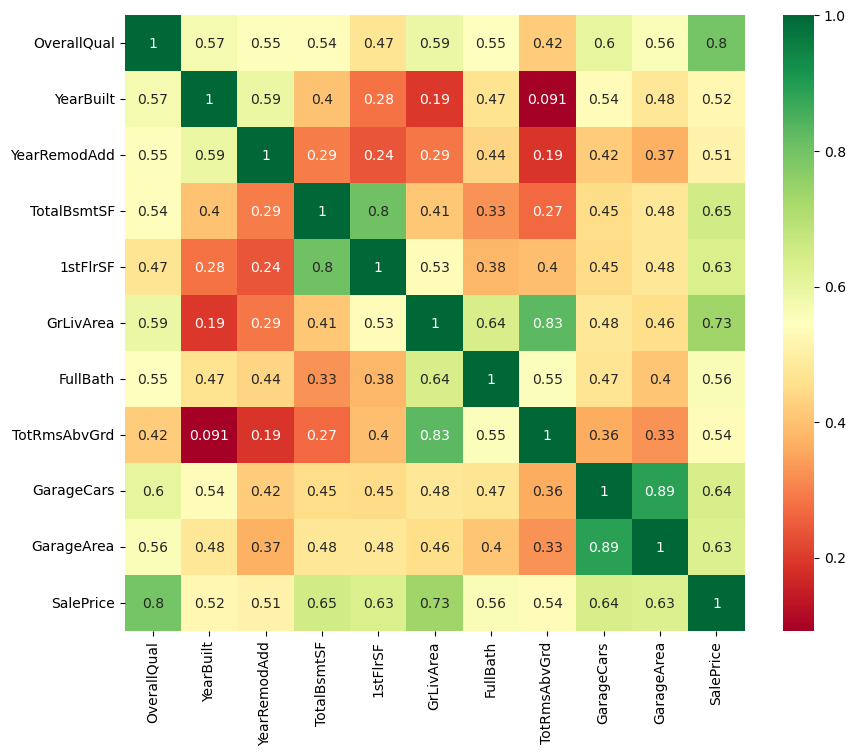

In [469]:
corrmat = df_train.corr(numeric_only=True)
top_corr_features = corrmat.index[abs(corrmat["SalePrice"]) > 0.5]
plt.figure(figsize=(10,8))
sns.heatmap(df_train[top_corr_features].corr(), annot=True, cmap="RdYlGn")

In [470]:
top_corr_features

Index(['OverallQual', 'YearBuilt', 'YearRemodAdd', 'TotalBsmtSF', '1stFlrSF',
       'GrLivArea', 'FullBath', 'TotRmsAbvGrd', 'GarageCars', 'GarageArea',
       'SalePrice'],
      dtype='object')

 заметим что признаки OverallQualб ,GrLivArea,TotalBsmtSF и др имеют хорошую линейную зависимость с таргетом# заметим что признаки OverallQualб ,GrLivArea,TotalBsmtSF и др имеют хорошую линейную зависимость с таргетом

<Axes: xlabel='OverallQual', ylabel='SalePrice'>

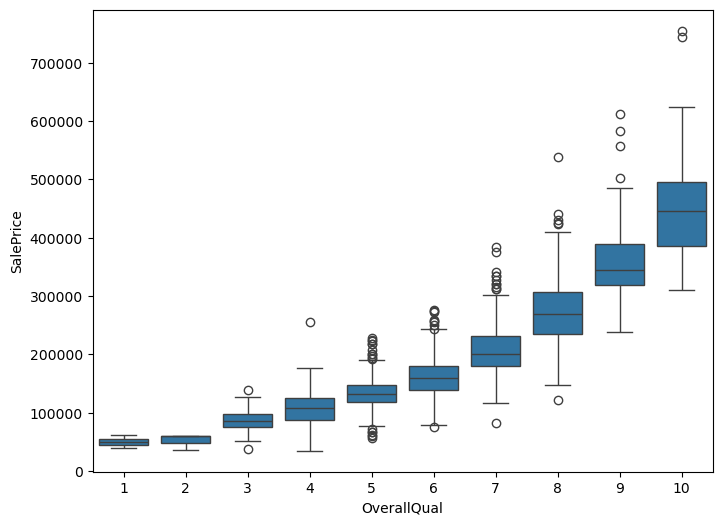

In [471]:
data = pd.concat([df_train['SalePrice'] ,df_train['OverallQual']], axis = 1)

plt.figure(figsize=(8, 6))
sns.boxplot(x='OverallQual', y="SalePrice", data=data)

признак категорильный, проследживается линейный тренд 

<Axes: xlabel='GrLivArea', ylabel='SalePrice'>

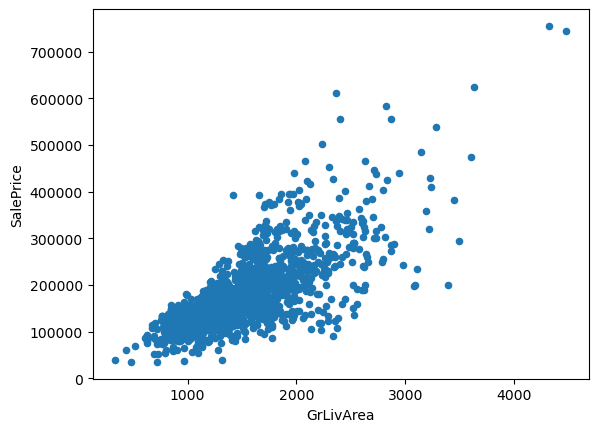

In [472]:
data = pd.concat([df_train['SalePrice'], df_train['GrLivArea']], axis=1)
data.plot.scatter(x='GrLivArea', y='SalePrice')

<Axes: xlabel='TotalBsmtSF', ylabel='SalePrice'>

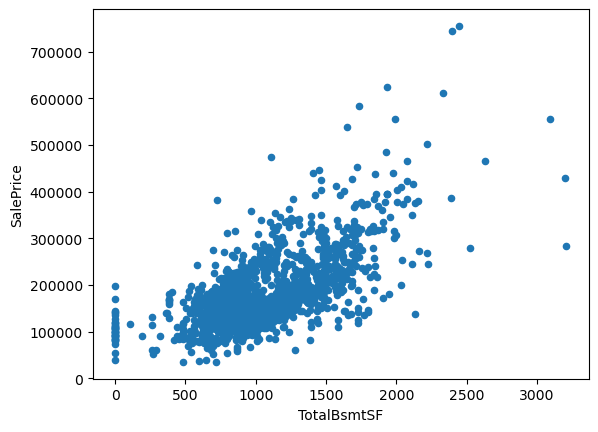

In [473]:
data = pd.concat([df_train['SalePrice'], df_train['TotalBsmtSF']], axis=1)
data.plot.scatter(x='TotalBsmtSF', y='SalePrice')

у этих признаков также прослеживается тренд 

<Axes: xlabel='Neighborhood', ylabel='SalePrice'>

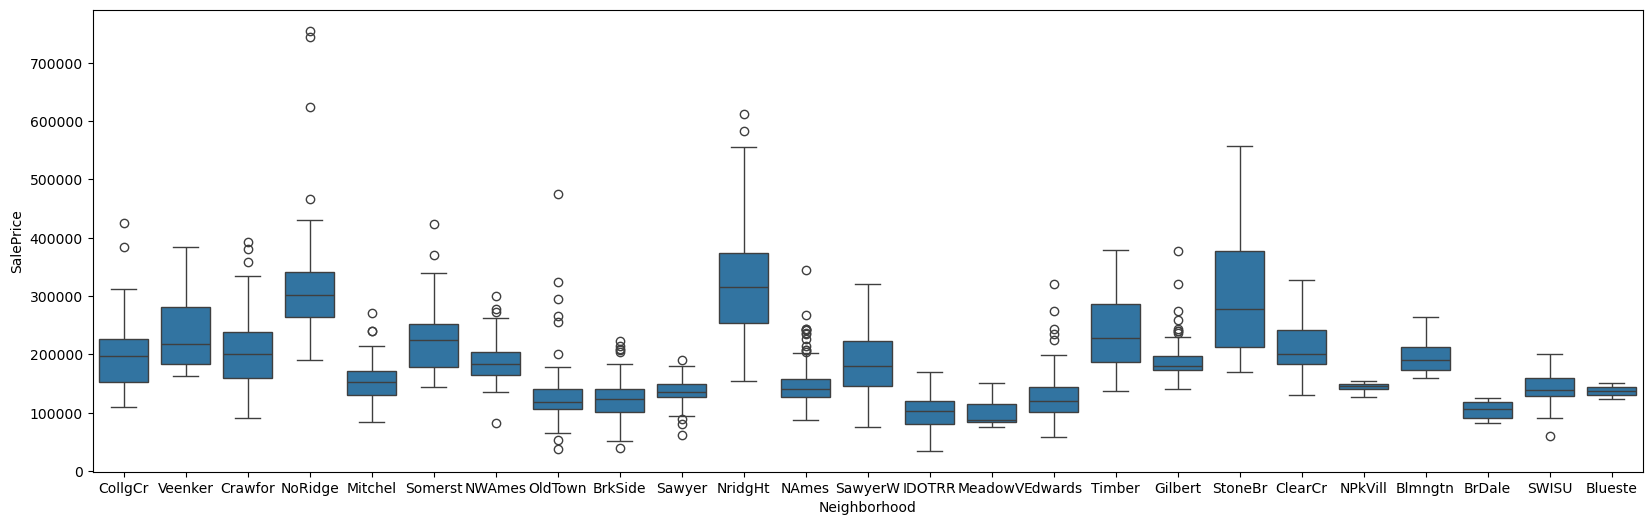

In [474]:
data = pd.concat([df_train['SalePrice'], df_train['Neighborhood']], axis=1)
plt.figure(figsize=(20, 6))
sns.boxplot(x='Neighborhood', y="SalePrice", data=data)

 cильной линейной зависимости не наблюдается но связь с таргетом определенно есть 

# заполняем пропуски 

выведем количество пустых строк и их долю 

In [475]:
total = df_train.isnull().sum().sort_values(ascending=False)
percent = (df_train.isnull().sum()/df_train.isnull().count()).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
missing_data.head(20)

,Total,Percent
PoolQC,1452,0.995885
MiscFeature,1404,0.962963
Alley,1367,0.937586
Fence,1177,0.807270
MasVnrType,872,0.598080
FireplaceQu,690,0.473251
LotFrontage,259,0.177641
GarageYrBlt,81,0.055556
GarageCond,81,0.055556
GarageType,81,0.055556


так как первые 7 признаков имеют большую долю пропущенных значений и их нет в списке самых коррелирующих, то их удалим остальные заполним модой


In [476]:
X = X.drop(list(missing_data[:7].index),axis = 1)
X = X.apply(lambda x:x.fillna(x.value_counts().index[0]))
X = X.drop('Id', axis = 1,errors='ignore')

In [477]:
list(missing_data[:7].index)

['PoolQC',
 'MiscFeature',
 'Alley',
 'Fence',
 'MasVnrType',
 'FireplaceQu',
 'LotFrontage']

In [478]:
X.shape

(1458, 72)

In [479]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   object 
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   object 
 6   Alley          107 non-null    object 
 7   LotShape       1459 non-null   object 
 8   LandContour    1459 non-null   object 
 9   Utilities      1457 non-null   object 
 10  LotConfig      1459 non-null   object 
 11  LandSlope      1459 non-null   object 
 12  Neighborhood   1459 non-null   object 
 13  Condition1     1459 non-null   object 
 14  Condition2     1459 non-null   object 
 15  BldgType       1459 non-null   object 
 16  HouseStyle     1459 non-null   object 
 17  OverallQual    1459 non-null   int64  
 18  OverallC

In [480]:
df_test = df_test.drop(
    list(missing_data[:7].index), 
    axis=1, 
    errors='ignore'  # Добавьте этот параметр
)
df_test = df_test.drop('Id', axis = 1, errors='ignore')

In [481]:
df_test = df_test.apply(lambda x:x.fillna(x.value_counts().index[0]))

In [482]:
df_test.shape

(1459, 72)

# нормализация данных 

In [483]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=42,shuffle=True)

X_train.shape, X_val.shape, y_train.shape, y_val.shape

((1093, 72), (365, 72), (1093,), (365,))

разделим признаки на непрерывные, категориалбные(порядковые и непорядковые)

In [484]:
X.select_dtypes(include = ['object']).columns


Index(['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional',
       'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive',
       'SaleType', 'SaleCondition'],
      dtype='object')

In [485]:
cat_features = X.select_dtypes(include='object').columns
cat_features

Index(['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional',
       'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive',
       'SaleType', 'SaleCondition'],
      dtype='object')

In [486]:
num_features = [col for col in X_train.columns if len(X_train[col].unique()) > 15 and X_train[col].dtype in ['float64','int64']]

num_features

['LotArea',
 'YearBuilt',
 'YearRemodAdd',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'GarageYrBlt',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'MiscVal']

In [487]:
ord_features = [col for col in X_train.columns if  (len(X_train[col].unique()) <= 15) and X_train[col].dtype in ['float64','int64']]

ord_features

['MSSubClass',
 'OverallQual',
 'OverallCond',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageCars',
 'PoolArea',
 'MoSold',
 'YrSold']

In [488]:
X[ord_features]

,MSSubClass,OverallQual,OverallCond,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageCars,PoolArea,MoSold,YrSold
0,60,7,5,1,0,2,1,3,1,8,0,2,0,2,2008
1,20,6,8,0,1,2,0,3,1,6,1,2,0,5,2007
2,60,7,5,1,0,2,1,3,1,6,1,2,0,9,2008
3,70,7,5,1,0,1,0,3,1,7,1,3,0,2,2006
4,60,8,5,1,0,2,1,4,1,9,1,3,0,12,2008
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,6,5,0,0,2,1,3,1,7,1,2,0,8,2007
1456,20,6,6,1,0,2,0,3,1,7,2,2,0,2,2010
1457,70,7,9,0,0,2,0,4,1,9,2,1,0,5,2010
1458,20,5,6,1,0,1,0,2,1,5,0,1,0,4,2010


In [489]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
        ('ord', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), ord_features)
    ], remainder= 'passthrough'
)



In [490]:
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)


In [491]:
y_train_log = np.log1p(y_train) 
y_val_log = np.log1p(y_val)   

# обучим baseline модель - линейную регрессию

In [492]:
model_lr = LinearRegression()
model_lr.fit(X_train_processed, y_train_log)
y_pred_lr_log = model_lr.predict(X_val_processed)
y_pred_lr = np.expm1(y_pred_lr_log)

In [723]:
def show_metrics(y_true, y_pred, model_name="Модель"):
    """Выводит метрики регрессии и график остатков"""
    
    # Метрики
    rmse = root_mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    # Вывод
    print(f"\n{model_name}:")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R2: {r2:.4f}")
    print(f"MAPE: {mape:.4f} ({mape*100:.2f}%)")
    
    # График остатков
    plt.figure(figsize=(8, 6))
    
    # Точки предсказаний
    plt.scatter(y_true, y_pred, alpha=0.6, edgecolors='k', linewidth=0.5)
    
    # Линия идеального предсказания (y=x)
    min_val = min(min(y_true), min(y_pred))
    max_val = max(max(y_true), max(y_pred))
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, 
             label='Идеальная линия (y=x)')
    
    plt.xlabel('Фактические значения (y_true)', fontsize=12)
    plt.ylabel('Предсказанные значения (y_pred)', fontsize=12)
    plt.title(f'Фактические vs Предсказанные: {model_name}', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    plt.tight_layout()
    plt.show()
    return rmse, mae, r2, mape
    


Линейная регрессия:
RMSE: 21437.7418
MAE: 15269.9258
R2: 0.9250
MAPE: 0.0927 (9.27%)


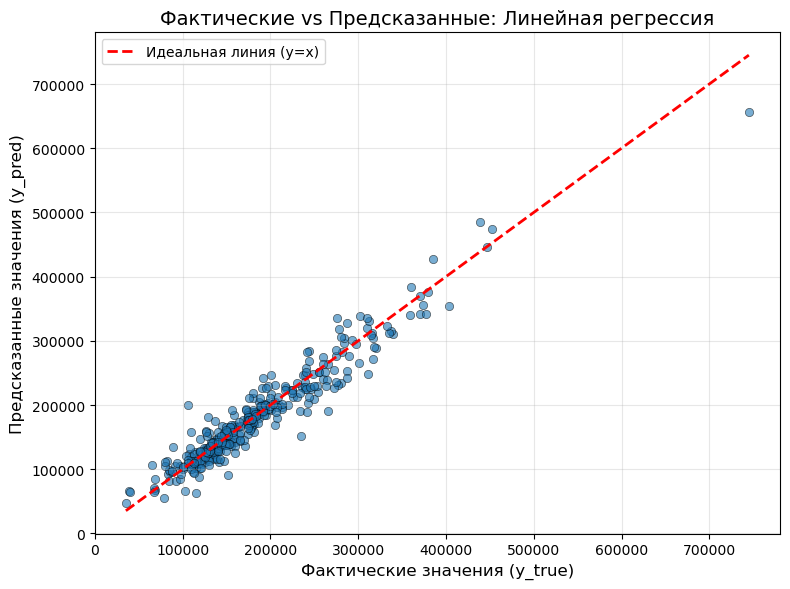

<Figure size 640x480 with 0 Axes>

(21437.741792327248,
 15269.92575644205,
 0.9249812756823049,
 0.09271657489385472)

In [724]:
show_metrics(y_val, y_pred_lr, model_name='Линейная регрессия')

In [495]:
print("Запуск k-fold кросс-валидации (k=5)...")
scores = cross_val_score(model_lr, X_train_processed, y_train_log, cv=5, n_jobs=-1)

print(f"Результаты по фолдам: {scores}")
print(f"Средняя точность: {scores.mean():.4f}")

Запуск k-fold кросс-валидации (k=5)...


0.01s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.01s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.01s - Debugger warning: It seems that frozen modules are being used, which may
0.01s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - Note: Debugging wil

Результаты по фолдам: [0.88790206 0.89557192 0.88653123 0.89086564 0.8983196 ]
Средняя точность: 0.8918


 находим аномалии которые портили нам метрику и удаляем их вначале кода

In [496]:
outliers = df_train[(df_train['GrLivArea'] > 4000) & (df_train['SalePrice'] < 300000)]
print(f"Найдено аномальных гигантов: {len(outliers)}")

Найдено аномальных гигантов: 0


# теперь обучим также и другие модификации линейной регрессии



Lasso регрессия:
RMSE: 18739.1988
MAE: 13776.5977
R2: 0.9427
MAPE: 0.0842 (8.42%)


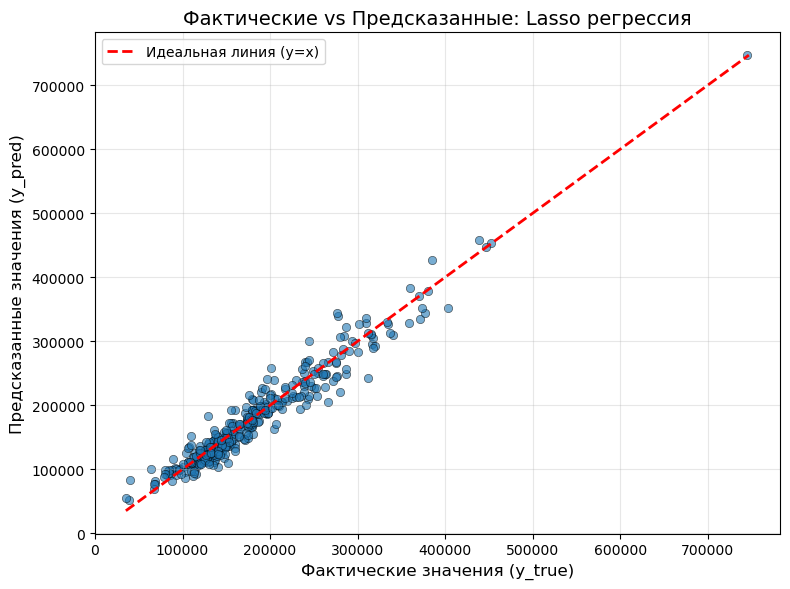

<Figure size 640x480 with 0 Axes>

In [497]:
# lasso
model_lasso = Lasso(alpha=0.001, random_state=42)

model_lasso.fit(X_train_processed, y_train_log)
y_pred_lasso_log = model_lasso.predict(X_val_processed)
y_pred_lasso = np.expm1(y_pred_lasso_log)
show_metrics(y_val, y_pred_lasso, model_name='Lasso регрессия')

In [498]:
print("Запуск k-fold кросс-валидации (k=5)...")
scores = cross_val_score(model_lasso, X_train_processed, y_train_log, cv=5, n_jobs=-1)

print(f"Результаты по фолдам: {scores}")
print(f"Средняя точность: {scores.mean():.4f}")

Запуск k-fold кросс-валидации (k=5)...
Результаты по фолдам: [0.91743889 0.88754304 0.89906864 0.93632222 0.92721921]
Средняя точность: 0.9135



Ridge регрессия:
RMSE: 20505.6130
MAE: 14691.9893
R2: 0.9314
MAPE: 0.0883 (8.83%)


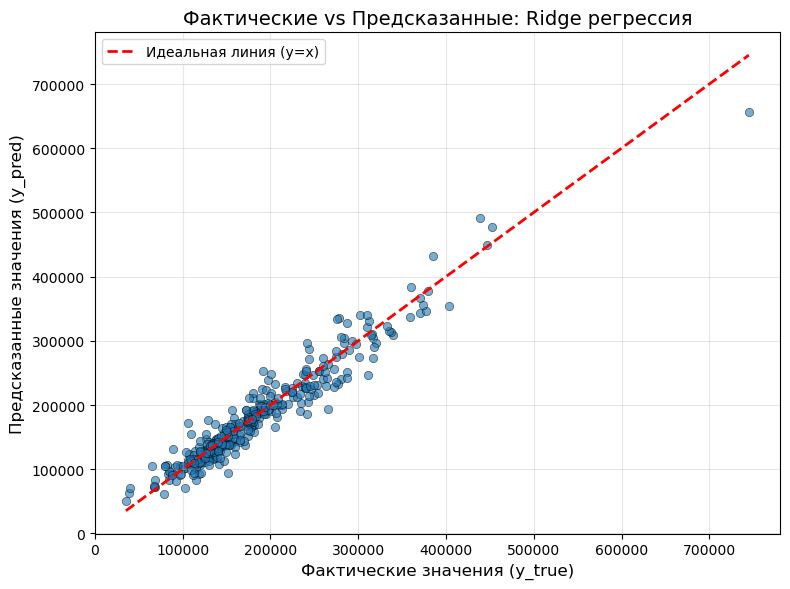

<Figure size 640x480 with 0 Axes>

In [499]:
# Ridge
model_ridge = Ridge(alpha=1.0, random_state=42)
model_ridge.fit(X_train_processed, y_train_log)
y_pred_ridge_log = model_ridge.predict(X_val_processed)
y_pred_ridge = np.expm1(y_pred_ridge_log)
show_metrics(y_val, y_pred_ridge, model_name='Ridge регрессия')


 ## попроубуем перебор гиперпараметров(GridSearch) для ElasticNet 


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Лучшие параметры: {'alpha': 0.001, 'l1_ratio': 0.5}
Лучший RMSE (лог): 0.1144

ElasticNet (оптимизированная):
RMSE: 18888.3382
MAE: 13817.0569
R2: 0.9418
MAPE: 0.0834 (8.34%)


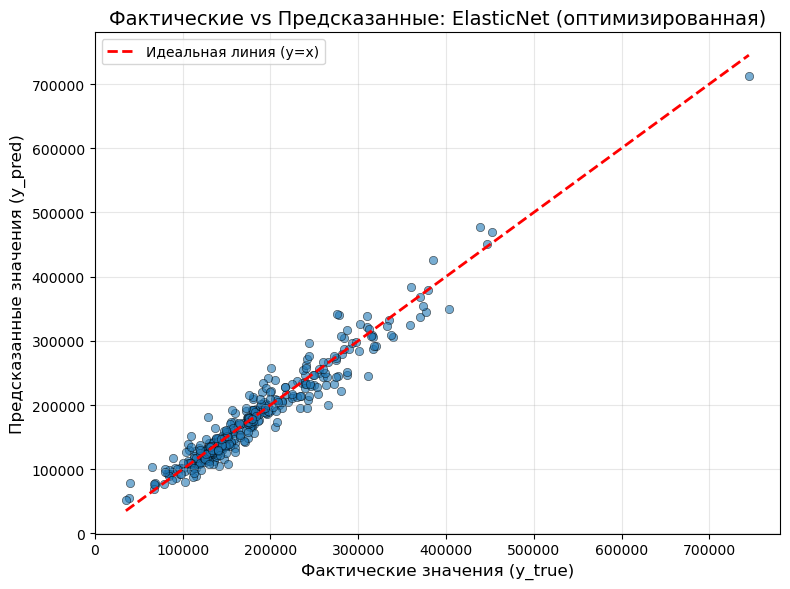

<Figure size 640x480 with 0 Axes>

In [500]:
param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1.0],
    'l1_ratio': [0.2, 0.5, 0.8]
}


grid_search = GridSearchCV(
    ElasticNet(random_state=42, max_iter=1000),
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)


grid_search.fit(X_train_processed, y_train_log)


best_elastic = grid_search.best_estimator_
print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Лучший RMSE (лог): {np.sqrt(-grid_search.best_score_):.4f}")


y_pred_log = best_elastic.predict(X_val_processed)
y_pred_el = np.expm1(y_pred_log)


show_metrics(y_val, y_pred_el, "ElasticNet (оптимизированная)")

# knn + randomsearch

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Лучшие параметры KNN: {'metric': 'manhattan', 'n_neighbors': 6, 'weights': 'distance'}
Лучший RMSE KNN (лог): 0.1651

KNN (оптимизированный):
RMSE: 31113.1946
MAE: 19558.9051
R2: 0.8420
MAPE: 0.1125 (11.25%)


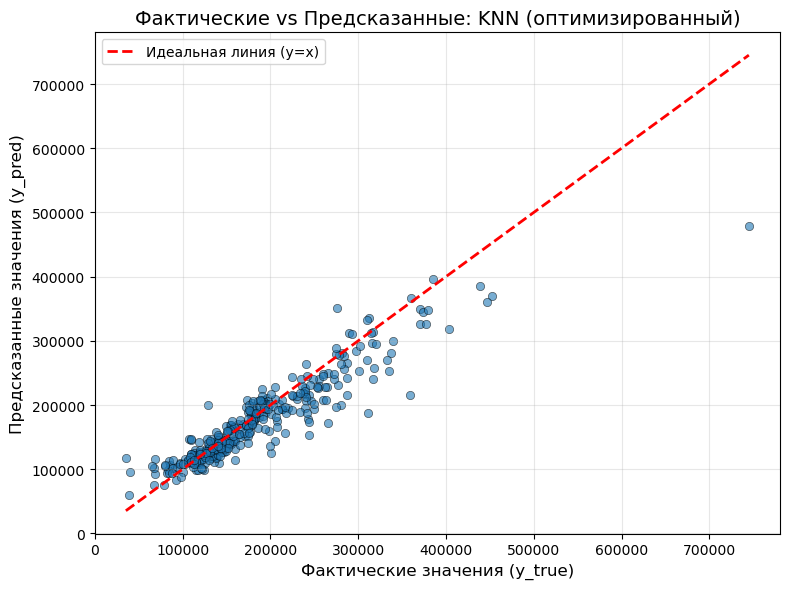

<Figure size 640x480 with 0 Axes>

In [501]:
model_knn = KNeighborsRegressor()

param_dist = {
    'n_neighbors': randint(1,30),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan'],
    
}

random_search_knn = RandomizedSearchCV(
    model_knn,
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search_knn.fit(X_train_processed, y_train_log)   
best_knn = random_search_knn.best_estimator_
print(f"Лучшие параметры KNN: {random_search_knn.best_params_}")
print(f"Лучший RMSE KNN (лог): {np.sqrt(-random_search_knn.best_score_):.4f}")
y_pred_knn_log = best_knn.predict(X_val_processed)
y_pred_knn = np.expm1(y_pred_knn_log)
show_metrics(y_val, y_pred_knn, "KNN (оптимизированный)")

# DesisionTreeRegressor


Decision Tree регрессия:
RMSE: 36336.1242
MAE: 25383.4010
R2: 0.7845
MAPE: 0.1496 (14.96%)


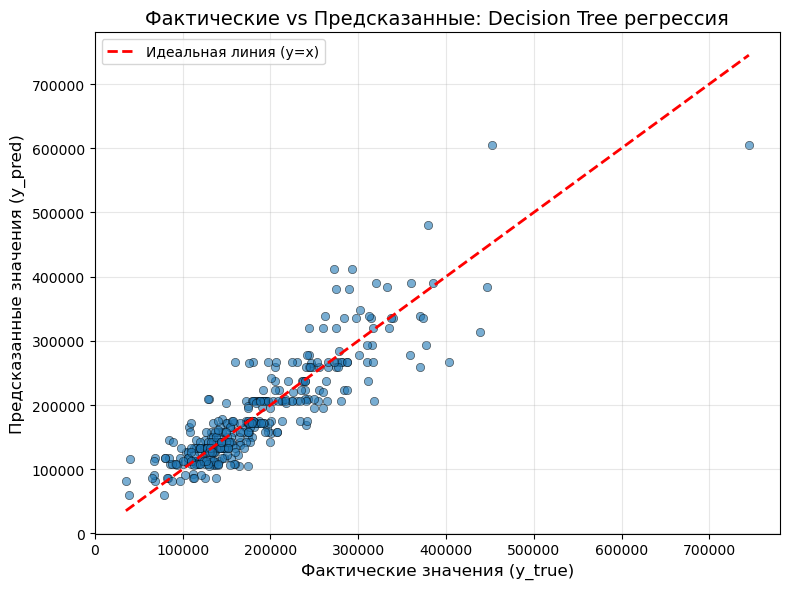

<Figure size 640x480 with 0 Axes>

In [502]:
model_dt = DecisionTreeRegressor(random_state=42, max_depth=6, min_samples_split=5, min_samples_leaf=5)
model_dt.fit(X_train_processed, y_train_log)
y_pred_dt_log = model_dt.predict(X_val_processed)
y_pred_dt = np.expm1(y_pred_dt_log)
show_metrics(y_val, y_pred_dt, model_name='Decision Tree регрессия')

# RandomForest + Random_Search 


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Лучшие параметры Random Forest: {'max_depth': 11, 'min_samples_leaf': 3, 'min_samples_split': 3}
Лучший RMSE Random Forest (лог): 0.3755

Random Forest (оптимизированный):
RMSE: 25625.9830
MAE: 16540.1248
R2: 0.8928
MAPE: 0.0987 (9.87%)


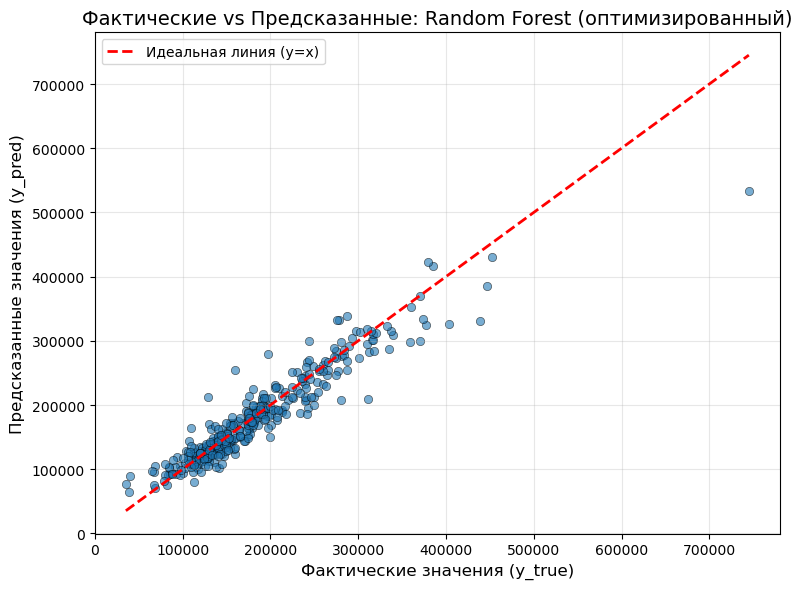

<Figure size 640x480 with 0 Axes>

In [503]:
grid_dist = {
    'max_depth': randint(4, 15),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 20)
}   

random_search_rf = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=grid_dist,
    n_iter=50,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
random_search_rf.fit(X_train_processed, y_train_log)
best_rf = random_search_rf.best_estimator_
print(f"Лучшие параметры Random Forest: {random_search_rf.best_params_}")
print(f"Лучший RMSE Random Forest (лог): {np.sqrt(-random_search_rf .best_score_):.4f}")
y_pred_rf_log = best_rf.predict(X_val_processed)    
y_pred_rf = np.expm1(y_pred_rf_log)
show_metrics(y_val, y_pred_rf, "Random Forest (оптимизированный)")

# CatBoost

Fitting 5 folds for each of 125 candidates, totalling 625 fits
Лучшие параметры: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 1000}
Лучший RMSE: 0.3433

Gradient Boosting (оптимизированный):
RMSE: 19596.6902
MAE: 13422.8497
R2: 0.9373
MAPE: 0.0787 (7.87%)


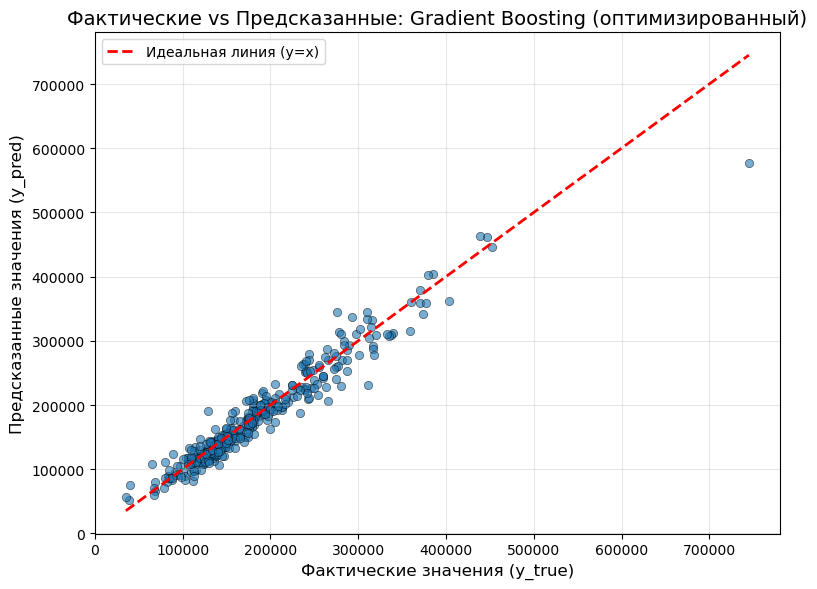

<Figure size 640x480 with 0 Axes>

In [ ]:
param_grid = {
    'n_estimators': [100, 300, 500, 700,1000],
    'learning_rate': [0.01,0.02, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6, 7]
}

# GridSearchCV (работает с CatBoost)
grid_search_gb = GridSearchCV(
    CatBoostRegressor(
        loss_function='RMSE',
        verbose=0,  # убираем вывод
        random_state=42,
        allow_writing_files=False
    ),
    param_grid=param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=0
)

if not hasattr(CatBoostRegressor, '__sklearn_tags__'):
    CatBoostRegressor.__sklearn_tags__ = lambda self: BaseEstimator.__sklearn_tags__(BaseEstimator())

# Обучаем
grid_search_gb.fit(X_train_processed, y_train_log)

# Результаты
best_gb = grid_search_gb.best_estimator_
print(f"Лучшие параметры: {grid_search_gb.best_params_}")
print(f"Лучший RMSE: {np.sqrt(-grid_search_gb.best_score_):.4f}")

# Предсказание
y_pred_gb_log = best_gb.predict(X_val_processed)    
y_pred_gb = np.expm1(y_pred_gb_log)
show_metrics(y_val, y_pred_gb, "Gradient Boosting (оптимизированный)")

In [505]:
print("Запуск k-fold кросс-валидации (k=5)...")
scores = cross_val_score(best_gb, X_train_processed, y_train_log, cv=5, n_jobs=-1)

print(f"Результаты по фолдам: {scores}")
print(f"Средняя точность: {scores.mean():.4f}")


Запуск k-fold кросс-валидации (k=5)...
Результаты по фолдам: [0.91421496 0.89026649 0.89570818 0.9145624  0.93865239]
Средняя точность: 0.9107


# 

# LightGBM

0.01s - Debugger warning: It seems that frozen modules are being used, which may
0.01s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.01s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.01s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0

Лучшие параметры: {'colsample_bytree': 0.9165974558680822, 'learning_rate': 0.039672930701554414, 'max_depth': 3, 'min_child_samples': 40, 'min_child_weight': 0.005357280069601832, 'n_estimators': 487, 'num_leaves': 11, 'reg_alpha': 0.013359166801651827, 'reg_lambda': 0.0010957420145894577, 'subsample': 0.7838501639099957}
Лучший RMSE: 0.3522

LGBM:
RMSE: 25251.6246
MAE: 15774.8770
R2: 0.8959
MAPE: 0.0900 (9.00%)


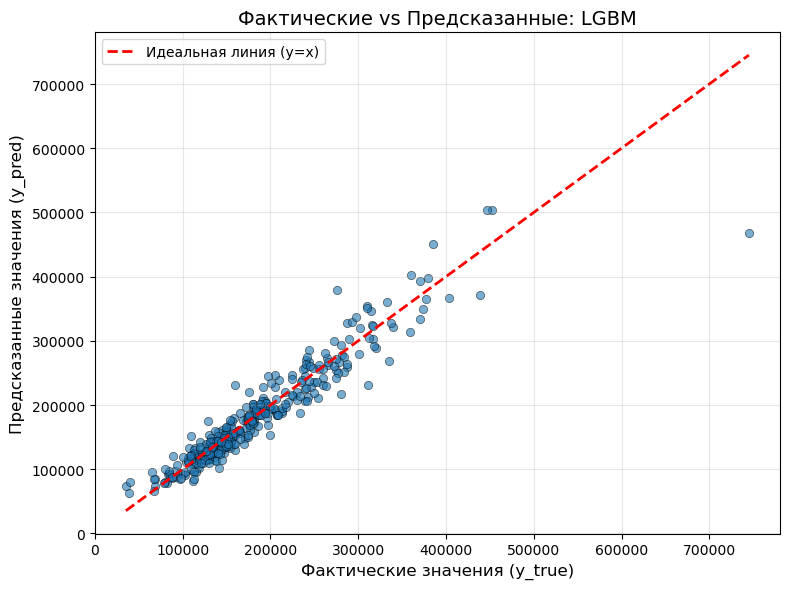

<Figure size 640x480 with 0 Axes>

In [704]:

param_dis_lgmb = {
    # Основные
    'n_estimators': randint(100, 1000),
    'learning_rate': uniform(0.005, 0.2),  # от 0.005 до 0.205
    'max_depth': randint(3, 15),
    'num_leaves': randint(10, 255),
    
    # Регуляризация
    'reg_alpha': loguniform(1e-4, 10),  # логарифмическое распределение
    'reg_lambda': loguniform(1e-4, 10),
    'subsample': uniform(0.5, 0.5),  # от 0.5 до 1.0
    'colsample_bytree': uniform(0.5, 0.5),
    'min_child_samples': randint(5, 100),
    'min_child_weight': loguniform(1e-3, 10),
}

model_lgbm  = RandomizedSearchCV(   
        LGBMRegressor(random_state=42,verbose=-1),
        param_dis_lgmb, 
        n_iter = 30, 
        cv = 5, 
        scoring = 'neg_root_mean_squared_error',
        random_state = 42,
        n_jobs= -1


    )

model_lgbm.fit(X_train_processed, y_train_log)

best_lgbm = model_lgbm.best_estimator_
print(f"Лучшие параметры: {model_lgbm.best_params_}")
print(f"Лучший RMSE: {np.sqrt(-model_lgbm.best_score_):.4f}")

y_pred_log_lgbm = best_lgbm.predict(X_val_processed)
y_pred_lgbm =np.expm1x(y_pred_log_lgbm)

show_metrics(y_val, y_pred_lgbm, "LGBM")



In [ ]:
print("Запуск k-fold кросс-валидации (k=5)...")
scores = cross_val_score(best_lgbm, X_train_processed, y_train_log, cv=5, n_jobs=-1)

print(f"Результаты по фолдам: {scores}")
print(f"Средняя точность: {scores.mean():.4f}")

Запуск k-fold кросс-валидации (k=5)...
Результаты по фолдам: [0.91313321 0.87014112 0.89181911 0.90366038 0.92603059]
Средняя точность: 0.9010


# XGBOOST



0.01s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.01s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.01s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.01s - Debugger warning: It seems that frozen modules are being used, which may
0


Лучшие параметры XGBoost: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 3, 'n_estimators': 700, 'subsample': 0.8}
Лучший RMSE на CV: 0.3496

XGBoost (GridSearch):
RMSE: 21440.1758
MAE: 14594.1641
R2: 0.9250
MAPE: 0.0845 (8.45%)


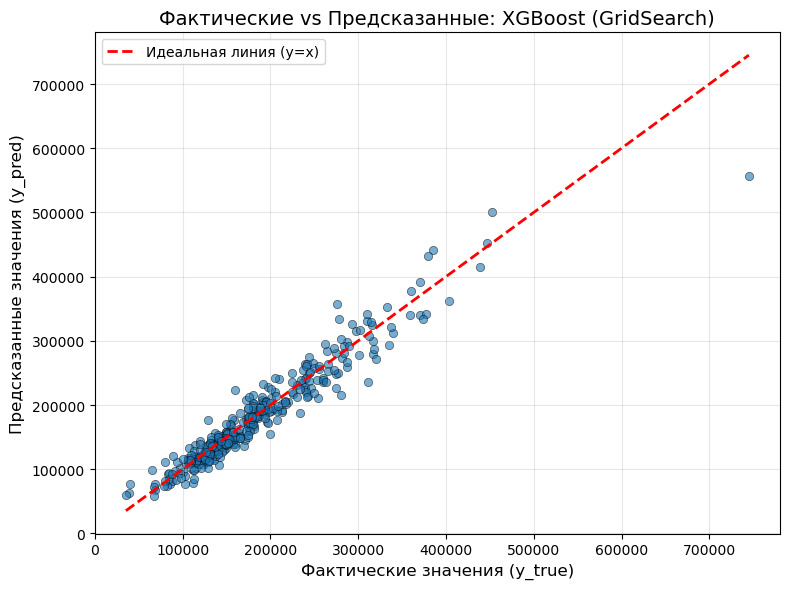

<Figure size 640x480 with 0 Axes>

In [ ]:
param_grid_xgb = {
    'n_estimators': [200, 300, 700],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}

model_xgb = GridSearchCV(
    XGBRegressor(random_state=42, objective='reg:squarederror'),
    param_grid_xgb,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=0
)

model_xgb.fit(X_train_processed, y_train_log)

best_xgb = model_xgb.best_estimator_
print(f"\nЛучшие параметры XGBoost: {model_xgb.best_params_}")
print(f"Лучший RMSE на CV: {np.sqrt( -model_xgb.best_score_):.4f}")

y_pred_log_xgb = best_xgb.predict(X_val_processed)
y_pred_xgb = np.expm1(y_pred_log_xgb)

show_metrics(y_val, y_pred_xgb, "XGBoost (GridSearch)")

# DNN

## simple nn

In [507]:
X_train_processed.shape, y_train_log.shape

((1093, 260), (1093,))

In [512]:
X_train_dense = X_train_processed.toarray() if hasattr(X_train_processed, 'toarray') else X_train_processed
X_train_tens = torch.FloatTensor(X_train_dense)
y_train_tens = torch.FloatTensor(y_train_log.values if hasattr(y_train_log, 'values') else y_train_log)

X_val_dense = X_val_processed.toarray() if hasattr(X_val_processed, 'toarray') else X_val_processed
X_val_tens = torch.FloatTensor(X_val_dense)
y_val_tens = torch.FloatTensor(y_val_log.values if hasattr(y_val_log, 'values') else y_val_log)

print(f" X_train: {X_train_tens.shape}, y_train: {y_train_tens.shape}")
print(f" X_val: {X_val_tens.shape}, y_val: {y_val_tens.shape}")

 X_train: torch.Size([1093, 260]), y_train: torch.Size([1093])
 X_val: torch.Size([365, 260]), y_val: torch.Size([365])


In [511]:
class MyDataset(Dataset):
    def __init__(self, x, y):
        self.x = x
        self.y = y
    def __len__(self):
        return len(self.x)
    
    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

In [513]:
train_dataset = MyDataset(X_train_tens, y_train_tens)
val_dataset = MyDataset(X_val_tens, y_val_tens)

train_loader = DataLoader(MyDataset(X_train_tens, y_train_tens), batch_size=32, shuffle=True)
val_loader = DataLoader(MyDataset(X_val_tens, y_val_tens), batch_size=32, shuffle=False)

iter(train_loader).__next__()


[tensor([[-0.1416,  0.1033, -0.5269,  ...,  0.0000,  6.0000,  2.0000],
         [-0.5738, -1.3480, -1.6931,  ...,  0.0000,  5.0000,  1.0000],
         [-0.2061, -0.2595,  0.8822,  ...,  0.0000,  1.0000,  0.0000],
         ...,
         [ 0.0226, -1.4800,  0.9308,  ...,  0.0000,  5.0000,  3.0000],
         [-0.0062,  0.2023,  0.7850,  ...,  0.0000,  1.0000,  4.0000],
         [-0.4046, -1.3480,  0.3477,  ...,  0.0000,  5.0000,  2.0000]]),
 tensor([12.1281, 11.3737, 11.9480, 11.8706, 11.9767, 12.7600, 11.7981, 12.1653,
         11.9512, 12.3842, 12.2549, 11.3621, 12.1308, 11.6082, 11.9704, 12.1705,
         12.0895, 12.9368, 12.4987, 11.7440, 12.1782, 12.9945, 11.8706, 11.9250,
         12.1222, 11.9050, 11.9892, 11.6263, 11.3504, 12.3631, 12.2308, 12.0009])]

In [514]:
class SimpleNN(nn.Module):
    def __init__(self, input_dim):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64, 1)
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x.squeeze()


In [579]:



def train_model(model,optimizer,loss_function, scheduler, train_loader, val_loader, epochs = 30):
    criterion = loss_function
    optimizer = optimizer
    val_loss = []
    train_loss = []

    for epoch in range(epochs):
        model.train()
        batch_loss_train = []
        batch_loss_val = []
        for x_batch, y_batch in train_loader:

            optimizer.zero_grad()
            outputs = model(x_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            batch_loss_train.append(loss.item())
        
        train_loss.append(np.mean(batch_loss_train))
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss[-1]:.4f}")


        model.eval()
        with torch.no_grad():
            for x_batch, y_batch in val_loader:
                outputs = model(x_batch)
                loss = criterion(outputs, y_batch)
                batch_loss_val.append(loss.item())
            val_loss.append(np.mean(batch_loss_val))
        scheduler.step(val_loss[-1])
        print(f"Epoch {epoch+1}/{epochs}, Val Loss: {val_loss[-1]:.4f}, lr: {optimizer.param_groups[0]['lr']:.6f}   ")
        

    return train_loss, val_loss


In [572]:
model_simple_nn = SimpleNN(input_dim=X_train_tens.shape[1])
adam_optimizer = optim.Adam(model_simple_nn.parameters(), lr=0.001)
mse_loss = nn.MSELoss()
scheduler = optim.lr_scheduler.ReduceLROnPlateau(adam_optimizer, mode='min', factor=0.5, patience=5)
train_loss, val_loss = train_model(model_simple_nn, adam_optimizer, mse_loss, scheduler, train_loader, val_loader, epochs=50)

Epoch 1/50, Train Loss: 81.1189
Epoch 1/50, Val Loss: 20.0931, lr: 0.001000   
Epoch 2/50, Train Loss: 4.5453
Epoch 2/50, Val Loss: 1.4533, lr: 0.001000   
Epoch 3/50, Train Loss: 0.8152
Epoch 3/50, Val Loss: 0.7674, lr: 0.001000   
Epoch 4/50, Train Loss: 0.5121
Epoch 4/50, Val Loss: 0.5542, lr: 0.001000   
Epoch 5/50, Train Loss: 0.3796
Epoch 5/50, Val Loss: 0.4444, lr: 0.001000   
Epoch 6/50, Train Loss: 0.3061
Epoch 6/50, Val Loss: 0.3617, lr: 0.001000   
Epoch 7/50, Train Loss: 0.2411
Epoch 7/50, Val Loss: 0.3111, lr: 0.001000   
Epoch 8/50, Train Loss: 0.1967
Epoch 8/50, Val Loss: 0.2661, lr: 0.001000   
Epoch 9/50, Train Loss: 0.1664
Epoch 9/50, Val Loss: 0.2300, lr: 0.001000   
Epoch 10/50, Train Loss: 0.1412
Epoch 10/50, Val Loss: 0.2019, lr: 0.001000   
Epoch 11/50, Train Loss: 0.1130
Epoch 11/50, Val Loss: 0.1759, lr: 0.001000   
Epoch 12/50, Train Loss: 0.0981
Epoch 12/50, Val Loss: 0.1618, lr: 0.001000   
Epoch 13/50, Train Loss: 0.0858
Epoch 13/50, Val Loss: 0.1444, lr: 0

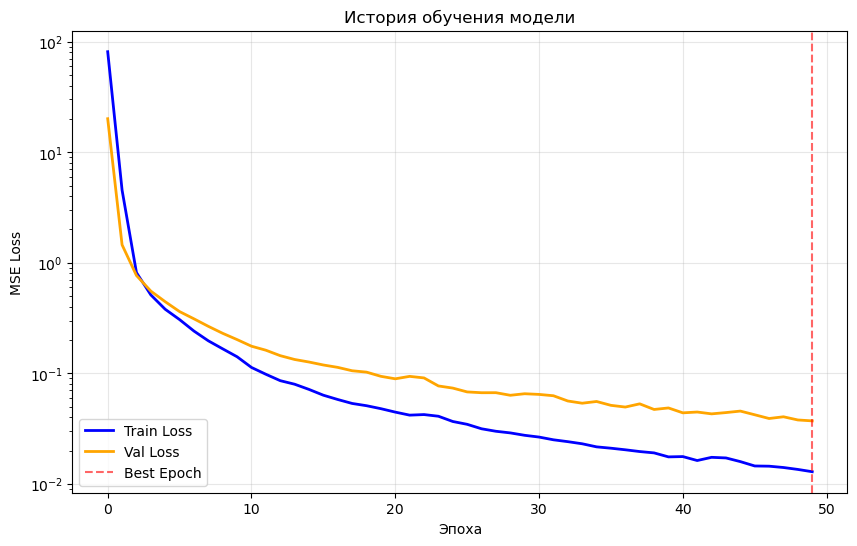

In [573]:
def plot_history(train_loss, val_loss):
    plt.figure(figsize=(10, 6))
    plt.plot(train_loss, label='Train Loss', color='blue', lw=2)
    plt.plot(val_loss, label='Val Loss', color='orange', lw=2)
    
    # Отмечаем точку минимума на валидации
    min_val_idx = np.argmin(val_loss)
    plt.axvline(min_val_idx, color='red', linestyle='--', alpha=0.6, label='Best Epoch')
    
    plt.title('История обучения модели')
    plt.xlabel('Эпоха')
    plt.ylabel('MSE Loss')
    plt.yscale('log') # Логарифмическая шкала полезна, если начальный лосс очень велик
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Вызов функции (передайте результаты вашей train_model)
plot_history(train_loss, val_loss)

In [586]:
def evaluate_model(model, loader):
    model.eval()
    y_true_log = []
    y_pred_log = []
    
    with torch.no_grad():
        for x_batch, y_batch in loader:
            outputs = model(x_batch)
            y_true_log.extend(y_batch.cpu().numpy())
            y_pred_log.extend(outputs.cpu().numpy())
            
   
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
   
    print(f"MAE:  {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R2:   {r2:.4f}")
    metrics = {'MAE': mae, 'RMSE': rmse, 'R2': r2}

    return y_true, y_pred, metrics
metrics_simple_nn = evaluate_model(model_simple_nn, val_loader)

MAE:  21256.26
RMSE: 29541.86
R2:   0.8575


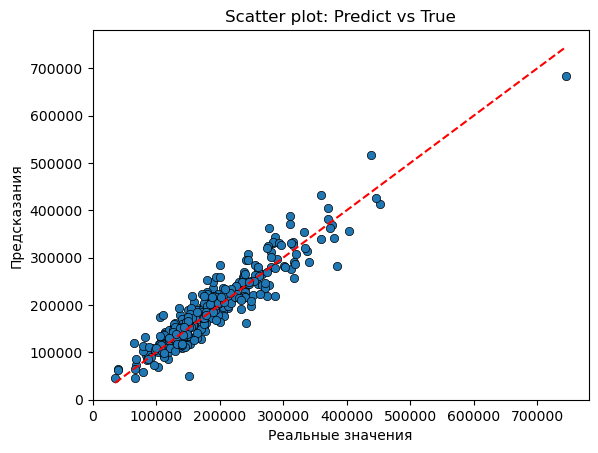

In [587]:
plt.scatter(y_true, y_pred, alpha=1.0, edgecolors='k', linewidth=0.5)
plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--') # Линия идеальных ответов
plt.xlabel('Реальные значения')
plt.ylabel('Предсказания')
plt.title('Scatter plot: Predict vs True')
plt.show()

## улучшенная nn

In [642]:
class ImprovedNN(nn.Module):
    def __init__(self, input_dim):
        super(ImprovedNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.LeakyReLU(0.1), 
            nn.Dropout(0.15),  
            
            nn.Linear(64, 32),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.1),
            
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        x = self.net(x)
        return x.squeeze()

In [701]:
model_imroved_nn = ImprovedNN(input_dim=X_train_tens.shape[1])
optimizer_improved = optim.AdamW(model_imroved_nn.parameters(), lr=0.01,weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer_improved, 'min', patience=5, factor=0.5)
train_loss_improved, val_loss_improved = train_model(model_imroved_nn, optimizer_improved, mse_loss, scheduler, train_loader, val_loader, epochs=200)

Epoch 1/200, Train Loss: 20.4947
Epoch 1/200, Val Loss: 1.7638, lr: 0.010000   
Epoch 2/200, Train Loss: 2.7477
Epoch 2/200, Val Loss: 1.6041, lr: 0.010000   
Epoch 3/200, Train Loss: 2.5520
Epoch 3/200, Val Loss: 0.3847, lr: 0.010000   
Epoch 4/200, Train Loss: 1.8471
Epoch 4/200, Val Loss: 0.2287, lr: 0.010000   
Epoch 5/200, Train Loss: 1.5401
Epoch 5/200, Val Loss: 0.1675, lr: 0.010000   
Epoch 6/200, Train Loss: 1.4518
Epoch 6/200, Val Loss: 0.1775, lr: 0.010000   
Epoch 7/200, Train Loss: 1.4501
Epoch 7/200, Val Loss: 0.2945, lr: 0.010000   
Epoch 8/200, Train Loss: 1.1926
Epoch 8/200, Val Loss: 0.6506, lr: 0.010000   
Epoch 9/200, Train Loss: 1.2327
Epoch 9/200, Val Loss: 0.1808, lr: 0.010000   
Epoch 10/200, Train Loss: 1.1518
Epoch 10/200, Val Loss: 1.2014, lr: 0.010000   
Epoch 11/200, Train Loss: 1.1897
Epoch 11/200, Val Loss: 0.1561, lr: 0.010000   
Epoch 12/200, Train Loss: 1.3547
Epoch 12/200, Val Loss: 0.1911, lr: 0.010000   
Epoch 13/200, Train Loss: 1.0889
Epoch 13/200

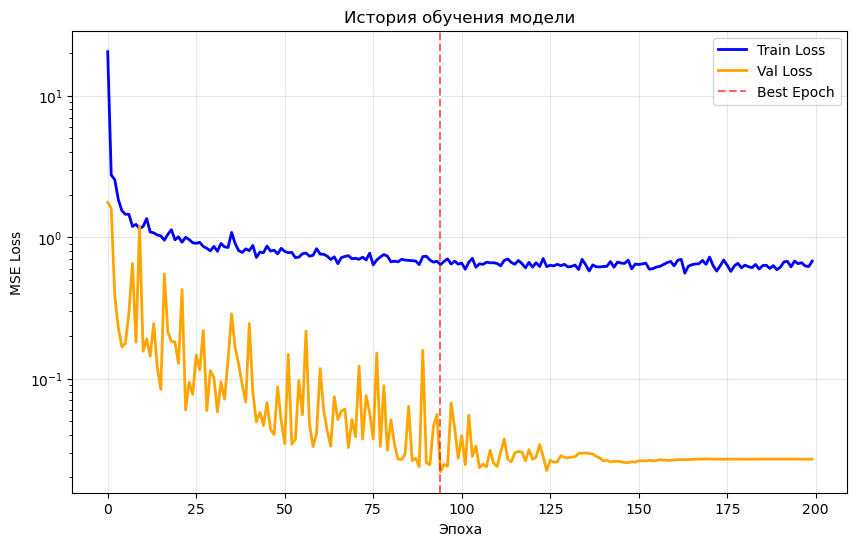

In [702]:
plot_history(train_loss_improved, val_loss_improved)

In [703]:
y_true_improved_nn, y_pred_improved_nn, metrics_improved_nn = evaluate_model(model_imroved_nn, val_loader)

MAE:  19883.67
RMSE: 26812.19
R2:   0.8827


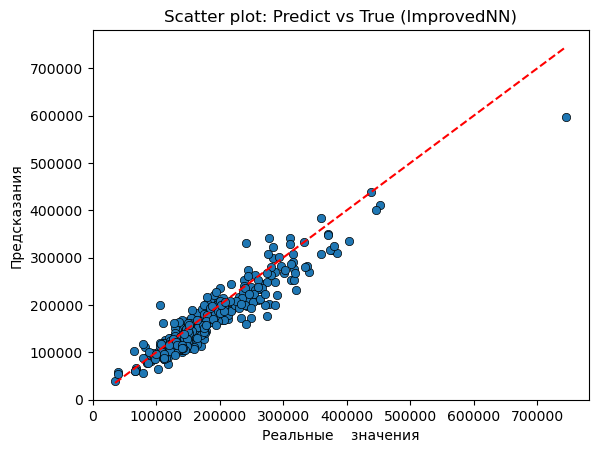

In [ ]:
plt.scatter(y_true_improved_nn, y_pred_improved_nn, alpha=1.0, edgecolors='k', linewidth=0.5)
plt.plot([min(y_true_improved_nn), max(y_true_improved_nn)], [min(y_true_improved_nn), max(y_true_improved_nn)], 'r--') # Линия идеальных ответов
plt.xlabel('Реальные    значения')
plt.ylabel('Предсказания')
plt.title('Scatter plot: Predict vs True (ImprovedNN)')
plt.show()  

# STACKING


Stacking Ensemble:
RMSE: 17451.6236
MAE: 12789.8167
R2: 0.9503
MAPE: 0.0776 (7.76%)


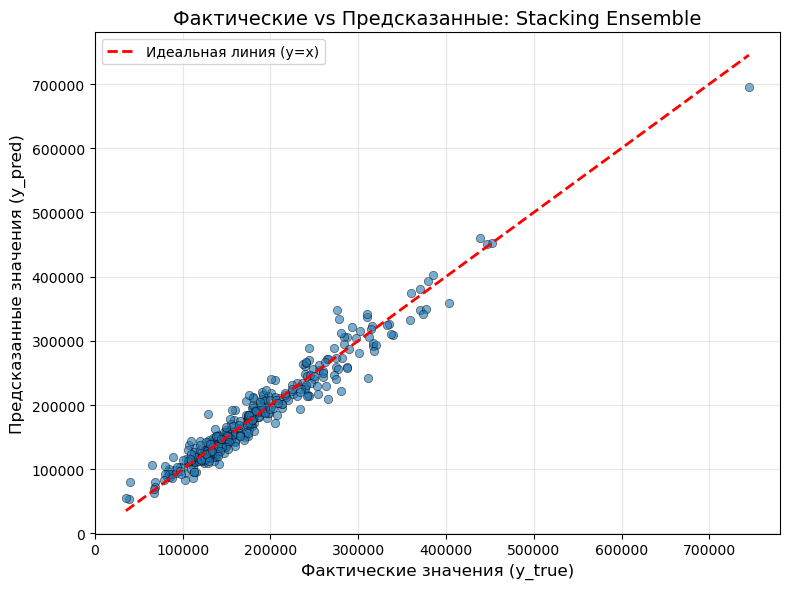

<Figure size 640x480 with 0 Axes>

In [715]:
X_meta = np.column_stack((y_pred_lr, y_pred_lasso, y_pred_ridge, y_pred_el, y_pred_rf, y_pred_gb, y_pred_lgbm, y_pred_xgb, y_pred_improved_nn))

meta_model = Ridge(alpha=1.0, random_state=42)
meta_model.fit(X_meta, y_val)
y_pred_stacking = meta_model.predict(X_meta)

show_metrics(y_val, y_pred_stacking, "Stacking Ensemble")


Метрики на обучающем наборе (OOF предсказания):

Stacking Ensemble (OOF):
RMSE: 20406.1116
MAE: 13118.2977
R2: 0.9347
MAPE: 0.0772 (7.72%)


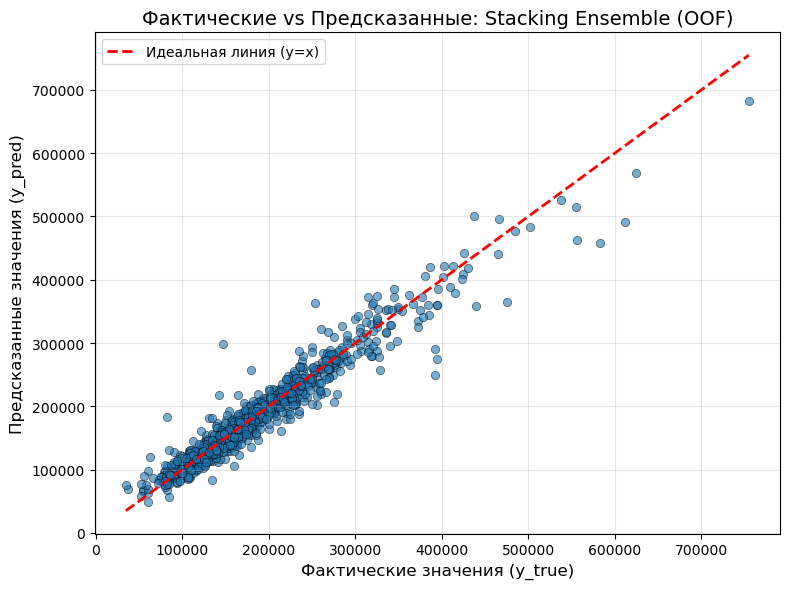

<Figure size 640x480 with 0 Axes>

In [716]:


models = [model_lr, model_lasso, model_ridge, best_elastic, best_rf, best_gb, best_lgbm, best_xgb]



oof_base_preds = []
for model in models:
    preds = cross_val_predict(model, X_train_processed, y_train_log, cv=5)
    oof_base_preds.append(preds)

oof_base_preds = np.column_stack(oof_base_preds)
meta_model.fit(oof_base_preds, y_train_log) 
oof_meta_preds = meta_model.predict(oof_base_preds)
oof_meta_preds_exp = np.expm1(oof_meta_preds)
y_train_exp = np.expm1(y_train_log)
print("\nМетрики на обучающем наборе (OOF предсказания):")
show_metrics(y_train_exp, oof_meta_preds_exp, "Stacking Ensemble (OOF)")

In [719]:
feature_names = ['LR', 'Lasso', 'Ridge', 'Elastic', 'RF', 'GB', 'LGBM', 'XGB']
coef_df = pd.DataFrame({'Model': feature_names, 'Weight': meta_model.coef_})
print(coef_df.sort_values(by='Weight', ascending=False))

     Model    Weight
3  Elastic  0.205035
2    Ridge  0.190810
7      XGB  0.156717
5       GB  0.154844
1    Lasso  0.141297
6     LGBM  0.112003
0       LR  0.038066
4       RF  0.008648


# итог

In [726]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Lasso', 'Ridge', 'ElasticNet', 'Random Forest', 'Gradient Boosting', 'LGBM', 'XGBoost', 'ImprovedNN', 'Stacking Ensemble'],
    'RMSE': [root_mean_squared_error(y_val, y_pred_lr),
             root_mean_squared_error(y_val, y_pred_lasso),
             root_mean_squared_error(y_val, y_pred_ridge),
             root_mean_squared_error(y_val, y_pred_el),
             root_mean_squared_error(y_val, y_pred_rf),
             root_mean_squared_error(y_val, y_pred_gb),
             root_mean_squared_error(y_val, y_pred_lgbm),
             root_mean_squared_error(y_val, y_pred_xgb),
             metrics_improved_nn['RMSE'],
             root_mean_squared_error(y_val, y_pred_stacking)]})
results = results.sort_values(by='RMSE').reset_index(drop=True)
print(results)

               Model          RMSE
0  Stacking Ensemble  17451.623572
1              Lasso  18739.198773
2         ElasticNet  18888.338150
3  Gradient Boosting  19596.690189
4              Ridge  20505.613031
5  Linear Regression  21437.741792
6            XGBoost  21440.175781
7               LGBM  25251.624649
8      Random Forest  25625.983008
9         ImprovedNN  26812.190660
